# Évolution des températures en France (2005–2025) selon les villes et les saisons

**Question :** Comment les températures moyennes ont-elles évolué selon les villes et les saisons en France entre 2005 et 2025 ?

**Source :** Météo-France — données climatologiques de base, quotidiennes (meteo.data.gouv.fr)

**Villes étudiées :** Paris (Montsouris), Toulouse (Blagnac), Lille (Lesquin), Poitiers (Biard), Lyon (Bron)


## 1. Présentation des données

Chargement des fichiers CSV téléchargés par département (75, 31, 59, 86, 69).

In [3]:
import pandas as pd
import glob

fichiers = glob.glob("data/*RR-T-Vent.csv")
print(fichiers)

stations = ["PARIS-MONTSOURIS", "TOULOUSE-BLAGNAC", "LILLE-LESQUIN", "POITIERS-BIARD", "LYON-BRON"]
colonnes_utiles = ["NUM_POSTE", "NOM_USUEL", "LAT", "LON", "AAAAMMJJ", "TN", "TX", "TM"]

dfs = []
for f in fichiers:
    df_tmp = pd.read_csv(f, sep=";", usecols=colonnes_utiles)
    df_tmp = df_tmp[df_tmp["NOM_USUEL"].isin(stations)]
    dfs.append(df_tmp)

df = pd.concat(dfs, ignore_index=True)
print(df.shape)
df.head()

['data/Q_31_previous-1950-2024_RR-T-Vent.csv', 'data/Q_59_previous-1950-2024_RR-T-Vent.csv', 'data/Q_69_previous-1950-2024_RR-T-Vent.csv', 'data/Q_75_previous-1950-2024_RR-T-Vent.csv', 'data/Q_86_previous-1950-2024_RR-T-Vent.csv']
(136970, 8)


,NUM_POSTE,NOM_USUEL,LAT,LON,AAAAMMJJ,TN,TX,TM
0,31069001,TOULOUSE-BLAGNAC,43.621,1.378833,19500101,3.0,5.0,5.0
1,31069001,TOULOUSE-BLAGNAC,43.621,1.378833,19500102,2.9,4.2,2.8
2,31069001,TOULOUSE-BLAGNAC,43.621,1.378833,19500103,-1.2,9.2,5.3
3,31069001,TOULOUSE-BLAGNAC,43.621,1.378833,19500104,6.2,10.0,8.5
4,31069001,TOULOUSE-BLAGNAC,43.621,1.378833,19500105,5.8,8.8,6.7


In [4]:
# On ne garde que les colonnes utiles et les 5 stations qui nous intéressent
stations = ["PARIS-MONTSOURIS", "TOULOUSE-BLAGNAC", "LILLE-LESQUIN", "POITIERS-BIARD", "LYON-BRON"]

colonnes_utiles = ["NUM_POSTE", "NOM_USUEL", "LAT", "LON", "AAAAMMJJ", "TN", "TX", "TM"]
df = df[[c for c in colonnes_utiles if c in df.columns]]

df = df[df["NOM_USUEL"].isin(stations)]
print(df["NOM_USUEL"].value_counts())
df.head()


NOM_USUEL
TOULOUSE-BLAGNAC    27394
LILLE-LESQUIN       27394
LYON-BRON           27394
PARIS-MONTSOURIS    27394
POITIERS-BIARD      27394
Name: count, dtype: int64


,NUM_POSTE,NOM_USUEL,LAT,LON,AAAAMMJJ,TN,TX,TM
0,31069001,TOULOUSE-BLAGNAC,43.621,1.378833,19500101,3.0,5.0,5.0
1,31069001,TOULOUSE-BLAGNAC,43.621,1.378833,19500102,2.9,4.2,2.8
2,31069001,TOULOUSE-BLAGNAC,43.621,1.378833,19500103,-1.2,9.2,5.3
3,31069001,TOULOUSE-BLAGNAC,43.621,1.378833,19500104,6.2,10.0,8.5
4,31069001,TOULOUSE-BLAGNAC,43.621,1.378833,19500105,5.8,8.8,6.7


## 2. Prétraitement / nettoyage

In [5]:
# Conversion de la date (format AAAAMMJJ) en datetime
df["date"] = pd.to_datetime(df["AAAAMMJJ"], format="%Y%m%d")

# On garde uniquement la période d'étude 2005-2025
df = df[(df["date"].dt.year >= 2005) & (df["date"].dt.year <= 2025)]

# Vérification des valeurs manquantes
print(df.isna().sum())


NUM_POSTE    0
NOM_USUEL    0
LAT          0
LON          0
AAAAMMJJ     0
TN           0
TX           0
TM           6
date         0
dtype: int64


In [6]:
# Suppression des doublons éventuels (même station, même date)
df = df.drop_duplicates(subset=["NUM_POSTE", "date"])

# On retire les lignes sans température moyenne (TM), notre variable principale
df = df.dropna(subset=["TM"])

print(df.shape)
df["TM"].describe()


(36519, 9)


count    36519.000000
mean        12.885377
std          6.862034
min         -9.200000
25%          7.800000
50%         12.800000
75%         18.000000
max         34.000000
Name: TM, dtype: float64

In [7]:
# Variables temporelles dérivées : année, mois, saison
df["annee"] = df["date"].dt.year
df["mois"] = df["date"].dt.month

def saison(mois):
    if mois in [12, 1, 2]:
        return "Hiver"
    elif mois in [3, 4, 5]:
        return "Printemps"
    elif mois in [6, 7, 8]:
        return "Été"
    else:
        return "Automne"

df["saison"] = df["mois"].apply(saison)

df = df.rename(columns={"NOM_USUEL": "ville"})
df[["ville", "date", "annee", "mois", "saison", "TN", "TX", "TM"]].head()


,ville,date,annee,mois,saison,TN,TX,TM
20089,TOULOUSE-BLAGNAC,2005-01-01,2005,1,Hiver,7.4,13.1,9.5
20090,TOULOUSE-BLAGNAC,2005-01-02,2005,1,Hiver,8.3,12.5,9.4
20091,TOULOUSE-BLAGNAC,2005-01-03,2005,1,Hiver,3.1,8.4,4.5
20092,TOULOUSE-BLAGNAC,2005-01-04,2005,1,Hiver,-2.2,9.0,2.3
20093,TOULOUSE-BLAGNAC,2005-01-05,2005,1,Hiver,-0.1,11.9,4.3


In [8]:
# Sauvegarde du dataset nettoyé pour la suite de l'analyse
df.to_csv("data/temperatures_clean.csv", index=False)
print("Fichier nettoyé enregistré :", df.shape)


Fichier nettoyé enregistré : (36519, 12)


## 3. Analyse exploratoire

Objectif : identifier les principales tendances de température entre 2005 et 2025 pour les cinq villes étudiées (statistiques descriptives, comparaisons villes/saisons).

### 3.1 Aperçu statistique

In [9]:
df["TM"].describe()

count    36519.000000
mean        12.885377
std          6.862034
min         -9.200000
25%          7.800000
50%         12.800000
75%         18.000000
max         34.000000
Name: TM, dtype: float64

In [10]:
df.describe()

,NUM_POSTE,LAT,LON,AAAAMMJJ,TN,TX,TM,date,annee,mois
count,3.651900e+04,36519.000000,36519.000000,3.651900e+04,36519.000000,36519.00000,36519.000000,36519,36519.000000,36519.000000
mean,6.411280e+07,47.065644,2.415878,2.014568e+07,8.786418,17.49164,12.885377,2015-01-01 03:25:21.564117248,2014.501383,6.523371
min,3.106900e+07,43.621000,0.314333,2.005010e+07,-13.400000,-5.50000,-9.200000,2005-01-01 00:00:00,2005.000000,1.000000
25%,5.934300e+07,45.721333,1.378833,2.009567e+07,4.300000,11.50000,7.800000,2009-12-31 12:00:00,2009.500000,4.000000
50%,6.902900e+07,46.593833,2.337833,2.015010e+07,9.000000,17.40000,12.800000,2015-01-01 00:00:00,2015.000000,7.000000
75%,7.511400e+07,48.821667,3.097500,2.020010e+07,13.600000,23.40000,18.000000,2020-01-01 12:00:00,2020.000000,10.000000
max,8.602700e+07,50.570000,4.949167,2.024123e+07,27.400000,42.60000,34.000000,2024-12-31 00:00:00,2024.000000,12.000000
std,1.865481e+07,2.419293,1.573464,5.766794e+04,6.160773,8.05379,6.862034,NaN,5.766700,3.448858


### 3.2 Température moyenne par ville

In [11]:
temp_ville = df.groupby("ville")["TM"].mean().sort_values(ascending=False)
print(temp_ville)

ville
TOULOUSE-BLAGNAC    14.308515
LYON-BRON           13.309747
PARIS-MONTSOURIS    12.950637
POITIERS-BIARD      12.412399
LILLE-LESQUIN       11.445202
Name: TM, dtype: float64


### 3.3 Température moyenne par année

In [12]:
temp_annee = df.groupby("annee")["TM"].mean()
print(temp_annee)

annee
2005    12.269644
2006    12.840219
2007    12.442630
2008    12.106667
2009    12.573425
2010    11.453041
2011    13.284066
2012    12.351475
2013    11.848932
2014    13.289808
2015    13.089041
2016    12.610328
2017    12.974247
2018    13.552164
2019    13.329167
2020    13.844863
2021    12.460932
2022    14.128712
2023    13.927233
2024    13.332787
Name: TM, dtype: float64


### 3.4 Température moyenne par saison

In [13]:
temp_saison = df.groupby("saison")["TM"].mean()
print(temp_saison)

saison
Automne      13.376110
Hiver         5.479202
Printemps    12.048880
Été          20.501228
Name: TM, dtype: float64


### 3.5 Température moyenne par ville et saison

In [14]:
ville_saison = df.groupby(["ville", "saison"])["TM"].mean()
print(ville_saison)

ville             saison   
LILLE-LESQUIN     Automne      12.008462
                  Hiver         4.707424
                  Printemps    10.623478
                  Été          18.319402
LYON-BRON         Automne      13.555165
                  Hiver         4.738504
                  Printemps    12.708098
                  Été          22.076848
PARIS-MONTSOURIS  Automne      13.242637
                  Hiver         5.878227
                  Printemps    12.281467
                  Été          20.268859
POITIERS-BIARD    Automne      12.957363
                  Hiver         5.475402
                  Printemps    11.451799
                  Été          19.635870
TOULOUSE-BLAGNAC  Automne      15.116923
                  Hiver         6.596454
                  Printemps    13.177609
                  Été          22.205163
Name: TM, dtype: float64


### 3.6 Nombre d'observations par ville

In [15]:
df["ville"].value_counts()

ville
TOULOUSE-BLAGNAC    7305
LILLE-LESQUIN       7305
LYON-BRON           7305
PARIS-MONTSOURIS    7305
POITIERS-BIARD      7299
Name: count, dtype: int64

### 3.7 Nombre d'observations par année

In [16]:
df["annee"].value_counts().sort_index()

annee
2005    1825
2006    1825
2007    1825
2008    1830
2009    1825
2010    1825
2011    1820
2012    1830
2013    1825
2014    1825
2015    1825
2016    1830
2017    1825
2018    1825
2019    1824
2020    1830
2021    1825
2022    1825
2023    1825
2024    1830
Name: count, dtype: int64

**Interprétation :** Les premières statistiques montrent les différences de températures entre les villes et les saisons. Les moyennes permettent d'identifier les villes les plus chaudes et les plus froides, tandis que la répartition des observations confirme que le jeu de données est équilibré sur la période étudiée.

## 4. Visualisations

Installation des librairies de visualisation (nécessaire sur JupyterLite).

In [17]:
import piplite
await piplite.install(["matplotlib", "seaborn"])

import matplotlib.pyplot as plt
import seaborn as sns

### 4.1 Évolution des températures moyennes par année

Objectif : observer l'évolution des températures entre 2005 et 2025 pour chaque ville.

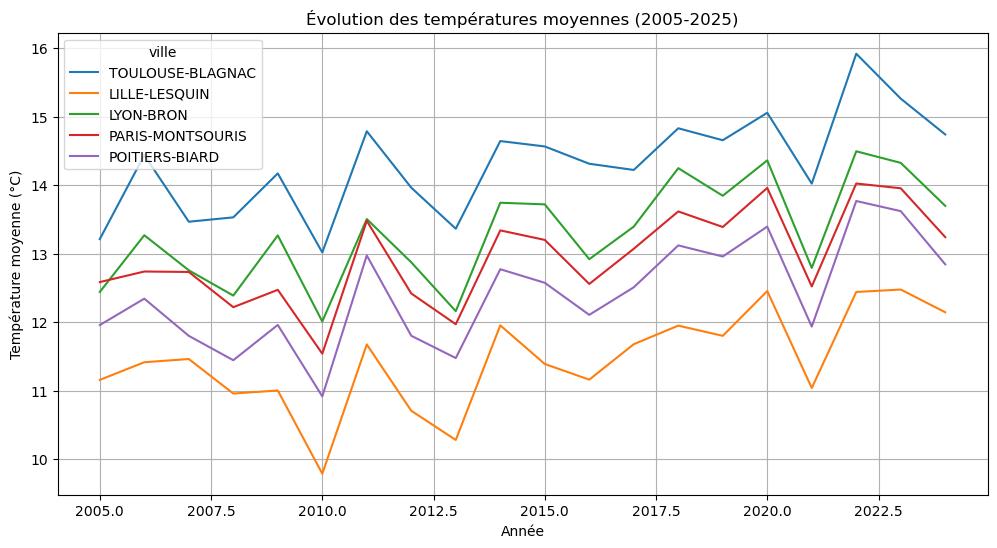

In [18]:
plt.figure(figsize=(12,6))
sns.lineplot(
    data=df,
    x="annee",
    y="TM",
    hue="ville",
    estimator="mean",
    errorbar=None
)
plt.title("Évolution des températures moyennes (2005-2025)")
plt.xlabel("Année")
plt.ylabel("Température moyenne (°C)")
plt.grid(True)
plt.show()

**Interprétation :** observe-t-on une hausse des températures ? Les villes évoluent-elles de la même manière ?

### 4.2 Température moyenne par saison

Objectif : comparer les saisons.

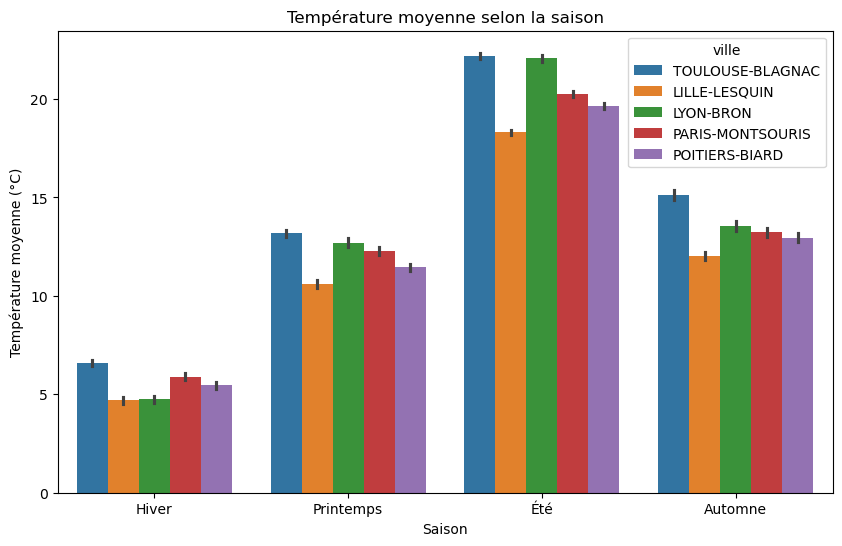

In [19]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=df,
    x="saison",
    y="TM",
    hue="ville"
)
plt.title("Température moyenne selon la saison")
plt.xlabel("Saison")
plt.ylabel("Température moyenne (°C)")
plt.show()

**Interprétation :** quelle saison est la plus chaude ? Les écarts entre les villes sont-ils importants ?

### 4.3 Distribution des températures par saison

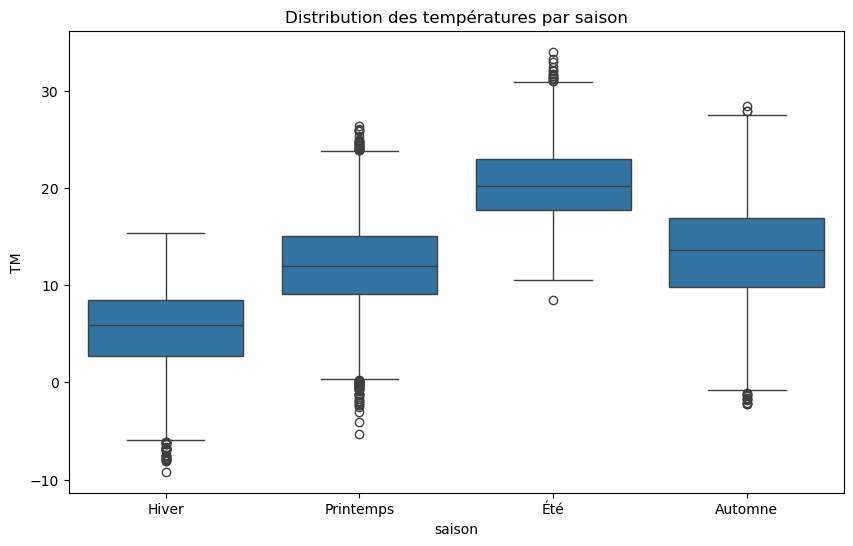

In [20]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x="saison",
    y="TM"
)
plt.title("Distribution des températures par saison")
plt.show()

**Interprétation :** quelle saison présente la plus grande dispersion ? Existe-t-il des valeurs extrêmes ?

### 4.4 Heatmap ville × saison

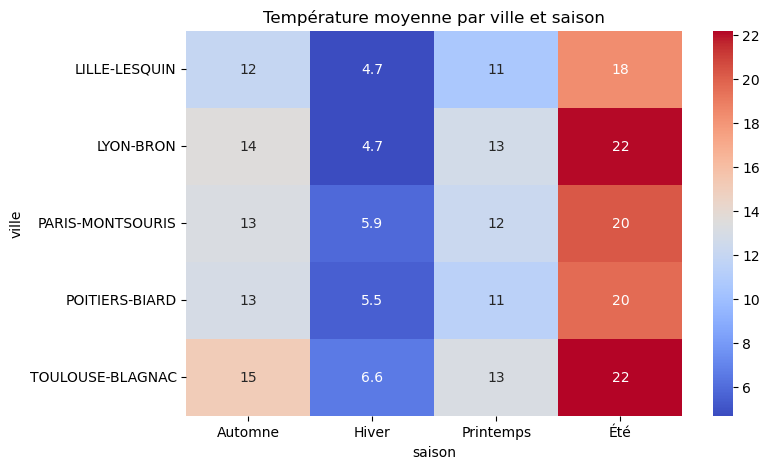

In [21]:
pivot = df.pivot_table(
    values="TM",
    index="ville",
    columns="saison",
    aggfunc="mean"
)

plt.figure(figsize=(8,5))
sns.heatmap(
    pivot,
    annot=True,
    cmap="coolwarm"
)
plt.title("Température moyenne par ville et saison")
plt.show()

**Interprétation :** comparer rapidement toutes les villes, identifier les combinaisons ville/saison les plus chaudes.

### 4.5 Température moyenne par mois

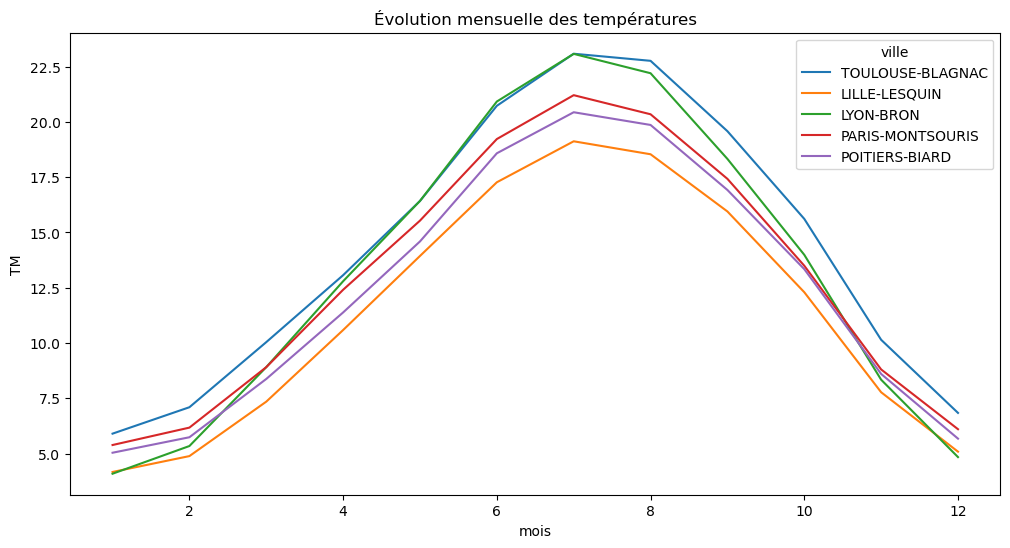

In [22]:
plt.figure(figsize=(12,6))
sns.lineplot(
    data=df,
    x="mois",
    y="TM",
    hue="ville",
    estimator="mean",
    errorbar=None
)
plt.title("Évolution mensuelle des températures")
plt.show()

**Interprétation :** quels mois sont les plus chauds ? Les profils saisonniers diffèrent-ils selon les villes ?

### 4.6 Histogramme des températures

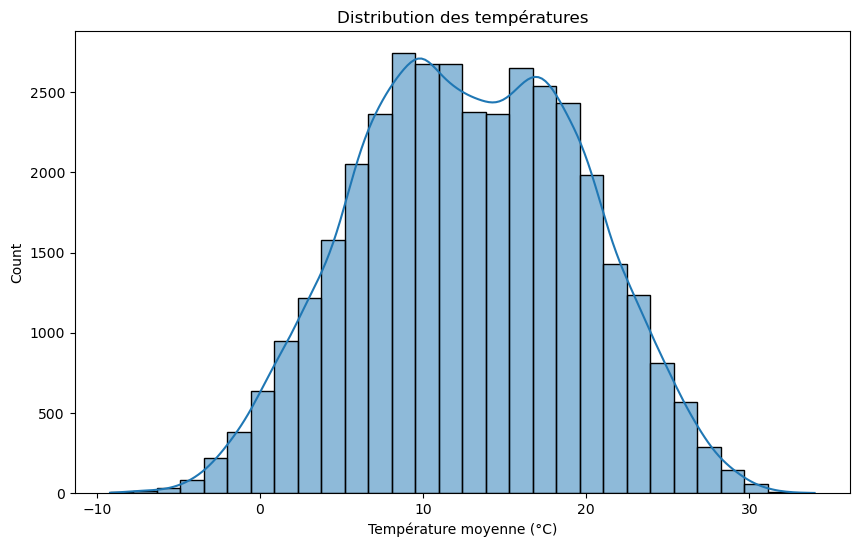

In [23]:
plt.figure(figsize=(10,6))
sns.histplot(
    data=df,
    x="TM",
    bins=30,
    kde=True
)
plt.title("Distribution des températures")
plt.xlabel("Température moyenne (°C)")
plt.show()

**Interprétation :** quelle est la répartition générale des températures ? Suivent-elles une distribution approximativement normale ?

## 5. Interprétation et discussion

**Objectif :** répondre à la question *"Comment les températures moyennes ont-elles évolué selon les villes et les saisons en France entre 2005 et 2025 ?"* à partir des résultats obtenus.

### Analyse des résultats

L'examen statistique met en évidence les tendances suivantes :

- **Gradient géographique** : les données confirment une variation thermique liée à la latitude ; les stations du sud (ex : Toulouse) présentent des moyennes systématiquement plus élevées que celles du nord (ex : Lille).
- **Stabilité saisonnière** : le cycle thermique annuel est constant, avec une saisonnalité marquée et prévisible pour chaque ville.
- **Dynamique temporelle** : l'analyse des courbes permet d'évaluer la tendance du réchauffement sur la période 2005-2025.
- **Dispersion thermique** : les boxplots indiquent une plus grande variabilité des températures durant les périodes de transition (hiver et printemps).

### Réponse à la problématique

Il est démontré que la température moyenne est déterminée principalement par la localisation géographique (station) et la saisonnalité. L'évolution sur vingt ans permet de caractériser le profil climatique spécifique de chaque zone étudiée.

### Limites de l'étude

- **Portée spatiale** : l'échantillon, restreint à cinq stations, ne permet pas une généralisation à l'échelle nationale.
- **Qualité des données** : la présence de valeurs manquantes nécessite une attention particulière lors du nettoyage, pouvant introduire des biais.
- **Paramètres climatiques** : l'étude se limite à la température, excluant des variables explicatives complémentaires telles que l'humidité, la pluviométrie ou le vent.


## 6. Conclusion

Cette étude a analysé l'évolution des températures moyennes dans cinq villes françaises (Paris, Toulouse, Lille, Poitiers, Lyon) de 2005 à 2025.

Grâce à un pipeline de traitement de données rigoureux — de l'importation à l'analyse exploratoire — nous avons mis en évidence le poids prépondérant de la localisation géographique et de la saisonnalité dans les disparités thermiques observées. Ce travail confirme que l'approche "question-driven" permet une lecture claire des tendances climatiques locales.

Ce projet pourra être enrichi par l'intégration d'un maillage plus dense de stations ou par la corrélation avec d'autres variables météorologiques (humidité, précipitations, vent) afin d'affiner la modélisation climatique.

### Références

- Météo-France, données climatologiques de base — quotidiennes, [meteo.data.gouv.fr](https://meteo.data.gouv.fr/)
